# SmartCar Price Estimator
### 5 ML Algorithms — Training Notebook

## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('All libraries imported successfully')

All libraries imported successfully


## Step 3 — Load Dataset

In [ ]:
# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/train.csv')

print('Dataset loaded successfully')
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.head()

Dataset loaded successfully
Rows: 19237
Columns: 18


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


## Step 4 — Data Cleaning

In [ ]:
# Levy column has '-' values, replace with 0 and convert to number
df['Levy'] = df['Levy'].replace('-', '0')
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce').fillna(0)

# Remove ' km' text from Mileage and convert to number
df['Mileage'] = df['Mileage'].str.replace(' km', '').str.replace(',', '')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce').fillna(0)

# Remove ' Turbo' text from Engine volume and convert to number
df['Engine volume'] = df['Engine volume'].str.replace(' Turbo', '')
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce').fillna(2.0)

# Doors column has date-like values, fix them
df['Doors'] = df['Doors'].replace({'02-Mar': 2, '04-May': 4, '>5': 6})
df['Doors'] = pd.to_numeric(df['Doors'], errors='coerce').fillna(4)

# Fill missing cylinder values with 4
df['Cylinders'] = df['Cylinders'].fillna(4)

# Remove price outliers
df = df[df['Price'] > 100]
df = df[df['Price'] <= 200000]

# Drop ID column as it is not useful for prediction
df = df.drop('ID', axis=1)

print('Data cleaning done')
print('Rows remaining:', df.shape[0])

Data cleaning done
Rows remaining: 18843


## Step 5 — Encoding and Train/Test Split

In [ ]:
# Convert text columns to numbers using Label Encoding
cat_cols = ['Manufacturer', 'Model', 'Category', 'Leather interior',
            'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le  # save encoder for later use in UI

print('Label encoding done')

# Separate features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data (required for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Label encoding done
Train size: 15074
Test size : 3769


## Step 6 — Train 5 Algorithms

In [ ]:
# Algorithm 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('1. Linear Regression  | R2:', round(r2_score(y_test, y_pred_lr), 4))

1. Linear Regression  | R2: 0.2068


In [ ]:
# Algorithm 2: Decision Tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('2. Decision Tree      | R2:', round(r2_score(y_test, y_pred_dt), 4))

2. Decision Tree      | R2: 0.5756


In [ ]:
# Algorithm 3: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('3. Random Forest      | R2:', round(r2_score(y_test, y_pred_rf), 4))

3. Random Forest      | R2: 0.7444


In [ ]:
# Algorithm 4: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print('4. Gradient Boosting  | R2:', round(r2_score(y_test, y_pred_gb), 4))

4. Gradient Boosting  | R2: 0.5938


In [ ]:
# Algorithm 5: SVR (uses scaled data)
svr = SVR(kernel='rbf', C=1000, gamma=0.1)
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
print('5. SVR                | R2:', round(r2_score(y_test, y_pred_svr), 4))

5. SVR                | R2: 0.4498


## Step 7 — Compare Results

In [ ]:
# Build results table for all 5 models
results = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVR'],
    'R2 Score': [
        round(r2_score(y_test, y_pred_lr),  4),
        round(r2_score(y_test, y_pred_dt),  4),
        round(r2_score(y_test, y_pred_rf),  4),
        round(r2_score(y_test, y_pred_gb),  4),
        round(r2_score(y_test, y_pred_svr), 4)
    ],
    'RMSE': [
        round(np.sqrt(mean_squared_error(y_test, y_pred_lr))),
        round(np.sqrt(mean_squared_error(y_test, y_pred_dt))),
        round(np.sqrt(mean_squared_error(y_test, y_pred_rf))),
        round(np.sqrt(mean_squared_error(y_test, y_pred_gb))),
        round(np.sqrt(mean_squared_error(y_test, y_pred_svr)))
    ],
    'MAE': [
        round(mean_absolute_error(y_test, y_pred_lr)),
        round(mean_absolute_error(y_test, y_pred_dt)),
        round(mean_absolute_error(y_test, y_pred_rf)),
        round(mean_absolute_error(y_test, y_pred_gb)),
        round(mean_absolute_error(y_test, y_pred_svr))
    ]
}

# Sort by best R2 score
results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df.index += 1
print(results_df)

# Save best model name
best_model_name = results_df.iloc[0]['Model']
print('\nBest Model:', best_model_name)

               Model  R2 Score   RMSE    MAE
1      Random Forest    0.7444   9007   4246
2  Gradient Boosting    0.5938  11354   6816
3      Decision Tree    0.5756  11605   6118
4                SVR    0.4498  13214   6908
5  Linear Regression    0.2068  15865  10614

Best Model: Random Forest


## Step 8 — Save Charts to assets folder

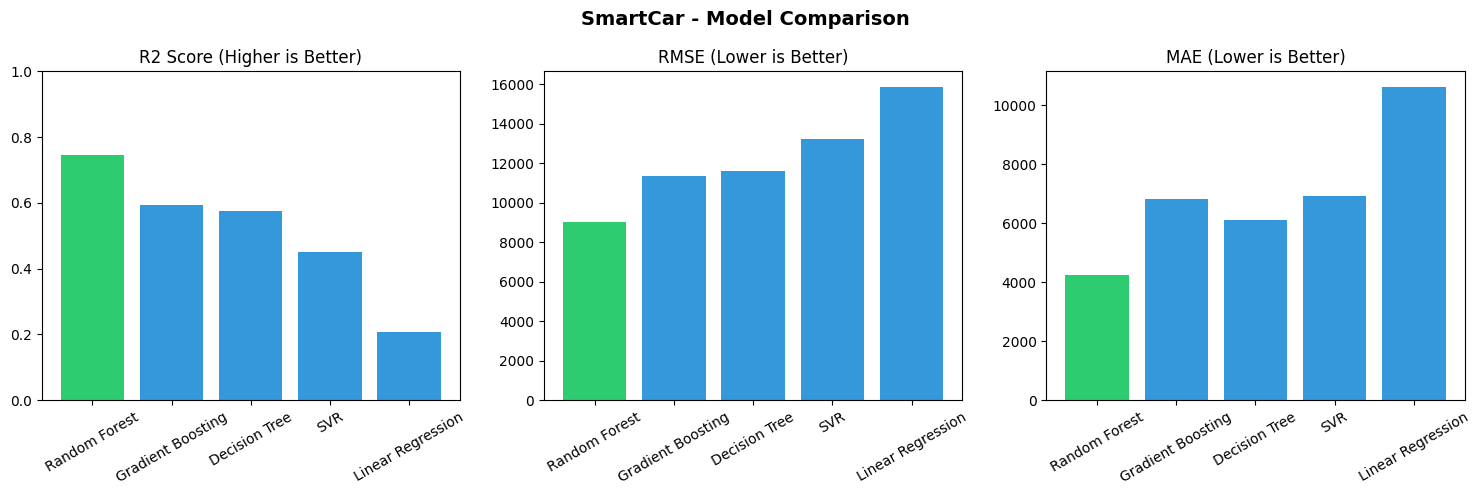

model_comparison.png saved to assets folder


In [ ]:
# Model comparison bar chart
# Green bar = best model, blue = others
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in results_df['Model']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('SmartCar - Model Comparison', fontsize=14, fontweight='bold')

axes[0].bar(results_df['Model'], results_df['R2 Score'], color=colors)
axes[0].set_title('R2 Score (Higher is Better)')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(results_df['Model'], results_df['RMSE'], color=colors)
axes[1].set_title('RMSE (Lower is Better)')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(results_df['Model'], results_df['MAE'], color=colors)
axes[2].set_title('MAE (Lower is Better)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('model_comparison.png saved to assets folder')

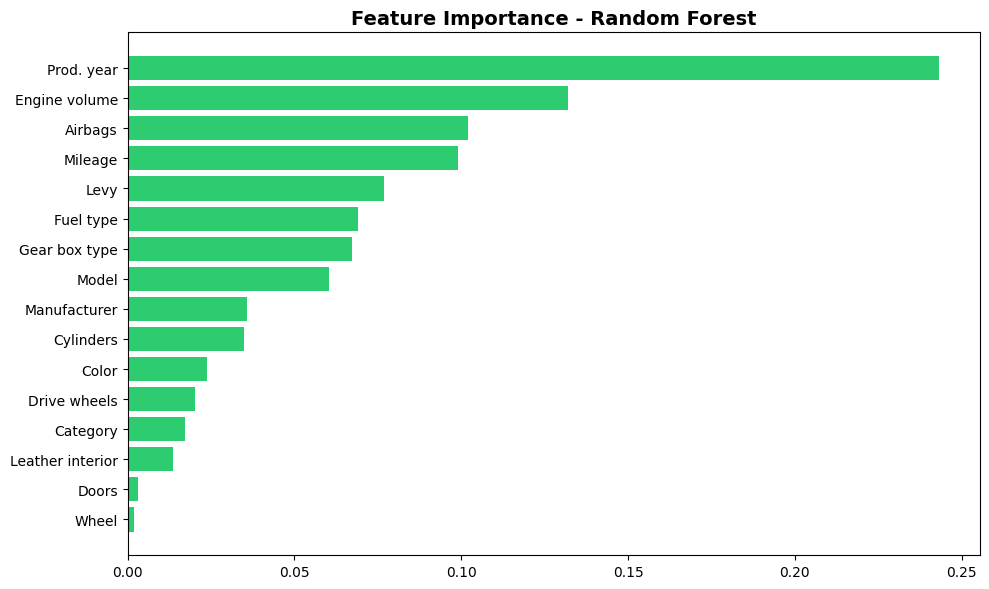

feature_importance.png saved to assets folder


In [ ]:
# Feature importance chart using Random Forest
feat_imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2ecc71')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/assets/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('feature_importance.png saved to assets folder')

## Step 9 — Save Model Files to models folder

In [ ]:
# Select best model object
all_models = {
    'Linear Regression': lr,
    'Decision Tree':     dt,
    'Random Forest':     rf,
    'Gradient Boosting': gb,
    'SVR':               svr
}
best_model = all_models[best_model_name]

# Save all files to models folder in Drive
pickle.dump(best_model,       open('/content/drive/MyDrive/models/best_model.pkl',      'wb'))
pickle.dump(scaler,           open('/content/drive/MyDrive/models/scaler.pkl',           'wb'))
pickle.dump(le_dict,          open('/content/drive/MyDrive/models/label_encoders.pkl',   'wb'))
pickle.dump(list(X.columns),  open('/content/drive/MyDrive/models/feature_names.pkl',    'wb'))
pickle.dump(best_model_name,  open('/content/drive/MyDrive/models/best_model_name.pkl',  'wb'))

print('All 5 files saved to models folder')
print('Best Model:', best_model_name)
print('Training complete. Now open SmartCar_UI notebook.')

All 5 files saved to models folder
Best Model: Random Forest
Training complete. Now open SmartCar_UI notebook.
